# Import

In [152]:
%load_ext autoreload
%autoreload 2

# Import required packages
import torch
import numpy as np
import normflows as nf
from torch.utils.data import TensorDataset, DataLoader, random_split

from matplotlib import pyplot as plt

from tqdm import trange

import joblib
import sklearn
import datetime

import sys
sys.path.append('../../src')
import ice

from scipy.io import savemat, loadmat
torch.multiprocessing.set_start_method('spawn', force=True)

import sklearn
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
Na_sim_v2 = pd.read_pickle("../../notebooks/Na_simulations/Na_sim_v2_df.pkl")

idx_example = 32457

Text(0.5, 1.0, 'ensemble, simulated full column $N_a$, variance: 27.86 dB')

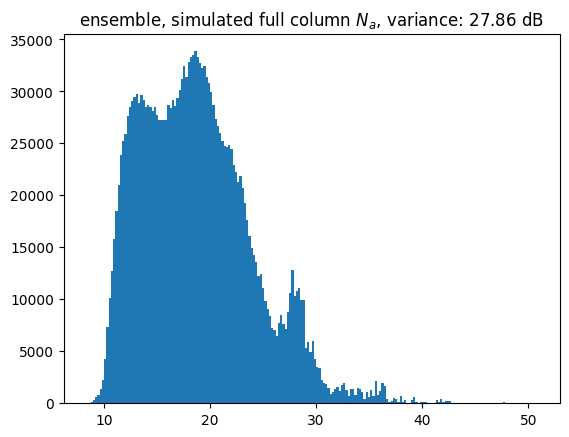

In [4]:
plt.hist(np.concatenate(Na_sim_v2['Na_full_sim'].to_numpy()), bins = 200);
plt.title(f"ensemble, simulated full column $N_a$, variance: {np.nanvar(np.concatenate(Na_sim_v2['Na_full_sim'].to_numpy())):.2f} dB")

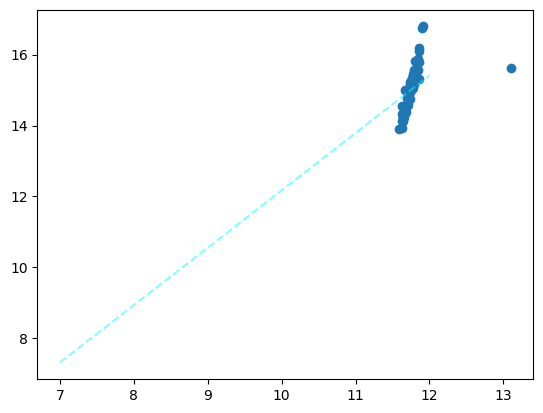

In [96]:
idx_example = 49031

Na_obs_sim_sample = Na_sim_v2['Na_obs_sim'][idx_example]
Na_full_sim_sample = Na_sim_v2['Na_full_sim'][idx_example]

plt.scatter(Na_obs_sim_sample, Na_full_sim_sample)

regression = sklearn.linear_model.LinearRegression(fit_intercept = True)
regression.fit(Na_obs_sim_sample.reshape(-1, 1), Na_full_sim_sample.reshape(-1, 1))
intercept_3 = regression.intercept_[0]
coef_3 = regression.coef_[0][0]
x_fit_3 = np.linspace(7, 12, 100)
y_fit_3 = x_fit_3 * coef_3 + intercept_3
n_3 = coef_3
# plt.scatter(Na_obs_sim_sample, Na_full_sim_sample, color = 'cyan', marker = "s", facecolors='none', alpha = 0.5)
plt.plot(x_fit_3, y_fit_3, c = 'cyan', ls = 'dashed', 
                label = rf'rheometer: $\dot{{\epsilon}} = {np.exp(intercept_3):.2f} \tau^{{{coef_3:.2f}}}, n = {n_3:.2f}$', alpha = 0.5)


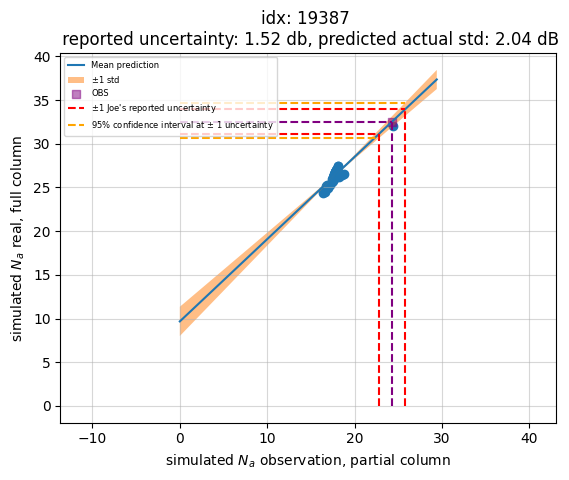

In [ ]:
idx_valid_sim = np.where(~Na_sim_v2.apply(lambda row: all(np.isnan(row['Na_full_sim'])), axis=1).to_numpy())[0]
idx_example = np.random.choice(idx_valid_sim)

Na_obs_sim_sample = Na_sim_v2['Na_obs_sim'][idx_example]
Na_full_sim_sample = Na_sim_v2['Na_full_sim'][idx_example]

Na_obs_sim_sample = Na_obs_sim_sample[~np.isnan(Na_obs_sim_sample)].reshape(-1, 1)
Na_full_sim_sample = Na_full_sim_sample[~np.isnan(Na_full_sim_sample)].reshape(-1, 1)

from sklearn.gaussian_process.kernels import RBF, WhiteKernel, DotProduct, ConstantKernel, Matern, RationalQuadratic, ExpSineSquared

kernel =  DotProduct() + ConstantKernel() #+ RBF(length_scale=20, length_scale_bounds=(1e-3, 1e3)) + WhiteKernel(noise_level=0)

gpr = sklearn.gaussian_process.GaussianProcessRegressor(kernel = kernel, alpha = 0.5)
gpr.fit(Na_obs_sim_sample, Na_full_sim_sample)

if (np.nanstd(Na_obs_sim_sample) < 0.1) or (np.nanstd(Na_full_sim_sample) < 0.1):
    print(np.nanstd(Na_obs_sim_sample))
    print("Not enough variance in samples. Fall back to reported uncertainty")

x_min = 0
x_max = np.max(Na_obs_sim_sample) + 5
X = np.arange(x_min, x_max, 0.01).reshape(-1, 1)

mean_prediction, std_prediction = gpr.predict(X, return_std=True)

# plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.plot(X, mean_prediction, label="Mean prediction")
plt.scatter(Na_sim_v2['Na_obs_sim'][idx_example], Na_sim_v2['Na_full_sim'][idx_example])
plt.fill_between(
    X.ravel(),
    mean_prediction - std_prediction,
    mean_prediction + std_prediction,
    alpha=0.5,
    label=rf"$\pm 1$ std",
)

Na_sample = Na_sim_v2['Na'][idx_example]
Na_uncert_sample = Na_sim_v2['Na_uncert'][idx_example]
Na_prediction = gpr.predict(Na_sample.reshape(1, -1))
plt.hlines(Na_prediction, x_min, Na_sample, color = 'purple', linestyles = 'dashed')
plt.vlines(Na_sample, 0, Na_prediction, color = 'purple', linestyles = 'dashed')
plt.scatter(Na_sample, Na_prediction, label = 'OBS', c = 'purple', alpha = 0.5, marker = 's')

Na_prediction_positive_uncert, Na_prediction_positive_uncert_std = gpr.predict((Na_sample + Na_uncert_sample).reshape(1, -1), return_std = True)
plt.hlines(Na_prediction_positive_uncert, x_min, Na_sample + Na_uncert_sample, color = 'red', linestyles = 'dashed')
plt.vlines(Na_sample + Na_uncert_sample, 0, Na_prediction_positive_uncert, color = 'red', linestyles = 'dashed')
plt.hlines(Na_prediction_positive_uncert + Na_prediction_positive_uncert_std, x_min, Na_sample + Na_uncert_sample, color = 'orange', linestyles = 'dashed')

Na_prediction_negative_uncert, Na_prediction_negative_uncert_std = gpr.predict((Na_sample - Na_uncert_sample).reshape(1, -1), return_std = True)
plt.hlines(Na_prediction_negative_uncert, x_min, Na_sample - Na_uncert_sample, color = 'red', linestyles = 'dashed')
plt.vlines(Na_sample - Na_uncert_sample, 0, Na_prediction_negative_uncert, color = 'red', linestyles = 'dashed',
            label = f"$\pm 1$ Joe's reported uncertainty")
plt.hlines(Na_prediction_negative_uncert - Na_prediction_negative_uncert_std, x_min, Na_sample - Na_uncert_sample, color = 'orange', linestyles = 'dashed',
            label = rf"95% confidence interval at $\pm$ 1 uncertainty")


plt.xlabel(rf"simulated $N_a$ observation, partial column")
plt.ylabel(rf"simulated $N_a$ real, full column")
plt.legend(fontsize = '6')

std = ((Na_prediction_positive_uncert + Na_prediction_positive_uncert_std) - (Na_prediction_negative_uncert - Na_prediction_negative_uncert_std)) / 2

plt.title(f'idx: {idx_example} \n reported uncertainty: {Na_uncert_sample:.2f} db, predicted actual std: {std[0]:.2f} dB')
plt.axis("equal")
plt.grid(alpha = 0.5)

In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

kernel =  DotProduct() + ConstantKernel() #+ RBF(length_scale=20, length_scale_bounds=(1e-3, 1e3)) + WhiteKernel(noise_level=0)

Na_uncert_predicted = np.full(Na_sim_v2.shape[0], np.nan)

for idx_radar in trange(Na_sim_v2.shape[0]):
    #print(idx_radar)
    Na_obs_sim_sample = Na_sim_v2['Na_obs_sim'][idx_radar]
    Na_full_sim_sample = Na_sim_v2['Na_full_sim'][idx_radar]

    Na_obs_sim_sample = Na_obs_sim_sample[~np.isnan(Na_obs_sim_sample)].reshape(-1, 1)
    Na_full_sim_sample = Na_full_sim_sample[~np.isnan(Na_full_sim_sample)].reshape(-1, 1)

    if (all(np.isnan(Na_full_sim_sample))) or (all(np.isnan(Na_obs_sim_sample))):
        continue
    if (np.nanstd(Na_full_sim_sample) < 0.1) or (np.nanstd(Na_obs_sim_sample) < 0.1):
        Na_uncert_predicted[idx_radar] = Na_sim_v2['Na_uncert'][idx_radar]
        #print(np.nanstd(Na_full_sim_sample))
        #print(np.nanstd(Na_obs_sim_sample))
        #print("Not enough variance in samples. Fall back to reported uncertainty")
        continue

    gpr = sklearn.gaussian_process.GaussianProcessRegressor(kernel = kernel, alpha = 0.25)
    gpr.fit(Na_obs_sim_sample, Na_full_sim_sample)

    mean_prediction, std_prediction = gpr.predict(X, return_std=True)

    Na_sample = Na_sim_v2['Na'][idx_radar]
    Na_uncert_sample = Na_sim_v2['Na_uncert'][idx_radar]

    Na_prediction = gpr.predict(Na_sample.reshape(1, -1))
    Na_prediction_positive_uncert, Na_prediction_positive_uncert_std = gpr.predict((Na_sample + Na_uncert_sample).reshape(1, -1), return_std = True)
    Na_prediction_negative_uncert, Na_prediction_negative_uncert_std = gpr.predict((Na_sample - Na_uncert_sample).reshape(1, -1), return_std = True)

    uncert_predicted = ((Na_prediction_positive_uncert + Na_prediction_positive_uncert_std) - (Na_prediction_negative_uncert - Na_prediction_negative_uncert_std)) / 2


    if len(uncert_predicted) > 1:
        raise Exception("Error")

    if uncert_predicted < 0:
        print("Regression slope < 1. Bad regression. Using reported uncertainty")
        Na_uncert_predicted[idx_radar] = Na_sim_v2['Na_uncert'][idx_radar]
    else:
        Na_uncert_predicted[idx_radar] = uncert_predicted[0]

np.savez("Na_uncert_predicted.npz", Na_uncert_predicted = Na_uncert_predicted)

 37%|███▋      | 22915/62296 [00:27<00:32, 1194.99it/s]

Bad regression. Using reported uncertainty
Bad regression. Using reported uncertainty
Bad regression. Using reported uncertainty
Bad regression. Using reported uncertainty
Bad regression. Using reported uncertainty


 96%|█████████▌| 59678/62296 [01:10<00:05, 495.58it/s]  

Bad regression. Using reported uncertainty


100%|██████████| 62296/62296 [01:12<00:00, 853.60it/s] 


(array([1.447e+03, 3.101e+03, 3.572e+03, 4.272e+03, 4.502e+03, 4.105e+03,
        3.329e+03, 2.808e+03, 2.411e+03, 1.819e+03, 1.399e+03, 1.202e+03,
        9.240e+02, 6.860e+02, 6.100e+02, 5.030e+02, 3.740e+02, 3.390e+02,
        2.870e+02, 2.140e+02, 2.240e+02, 1.560e+02, 1.540e+02, 1.130e+02,
        1.200e+02, 9.900e+01, 8.300e+01, 8.900e+01, 6.800e+01, 6.000e+01,
        4.700e+01, 4.400e+01, 4.600e+01, 3.400e+01, 3.000e+01, 3.400e+01,
        4.300e+01, 2.300e+01, 2.700e+01, 1.500e+01, 2.500e+01, 1.800e+01,
        1.400e+01, 1.400e+01, 1.200e+01, 1.300e+01, 8.000e+00, 4.000e+00,
        1.300e+01, 6.000e+00, 6.000e+00, 7.000e+00, 6.000e+00, 1.100e+01,
        5.000e+00, 8.000e+00, 4.000e+00, 2.000e+00, 3.000e+00, 5.000e+00,
        7.000e+00, 2.000e+00, 5.000e+00, 2.000e+00, 3.000e+00, 2.000e+00,
        5.000e+00, 2.000e+00, 3.000e+00, 2.000e+00, 1.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 3.000e+00, 2.000e+00, 1.000e+00,
        0.000e+00, 3.000e+00, 0.000e+0

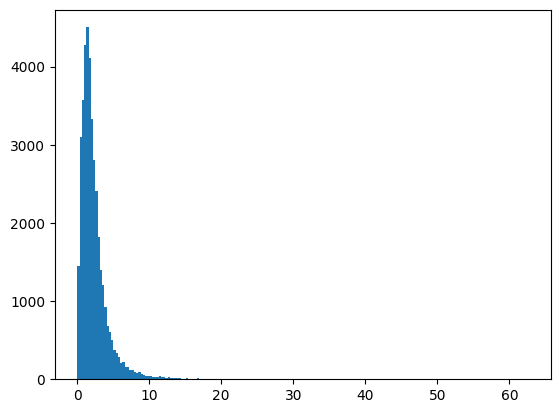

In [166]:
plt.hist(Na_uncert_predicted.flatten(), bins = 200)

Text(0.5, 1.0, 'dB')

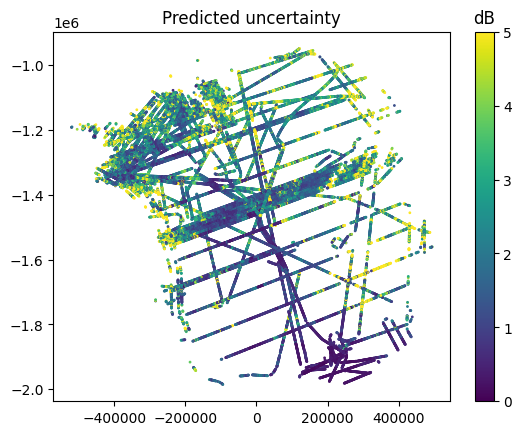

In [160]:
Na_uncert_predicted = np.load("Na_uncert_predicted.npz")['Na_uncert_predicted']

vmin, vmax = [0, 5]
im1 = plt.scatter(Na_sim_v2['radar_x'][~np.isnan(Na_uncert_predicted)], Na_sim_v2['radar_y'][~np.isnan(Na_uncert_predicted)], 
    s = 1, c = Na_uncert_predicted[~np.isnan(Na_uncert_predicted)], vmin = vmin, vmax = vmax)
cb1 = plt.colorbar(im1)
plt.title("Predicted uncertainty")
cb1.ax.set_title("dB")

Text(0.5, 1.0, 'dB')

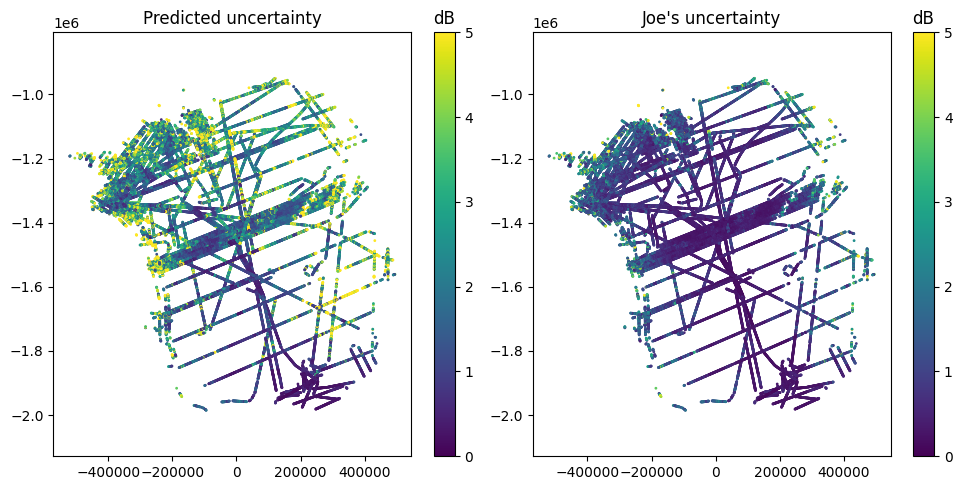

In [161]:
fig, ax = plt.subplots(1, 2, figsize = (10, 5), layout = 'tight')

vmin, vmax = [0, 5]
im0 = ax[0].scatter(Na_sim_v2['radar_x'][~np.isnan(Na_uncert_predicted)], Na_sim_v2['radar_y'][~np.isnan(Na_uncert_predicted)], 
    s = 1, c = Na_uncert_predicted[~np.isnan(Na_uncert_predicted)], vmin = vmin, vmax = vmax)
ax[0].set_title("Predicted uncertainty")
ax[0].axis('equal')
cb0 = plt.colorbar(im0)
cb0.ax.set_title("dB")

vmin, vmax = [0, 5]
im1 = ax[1].scatter(Na_sim_v2['radar_x'][~np.isnan(Na_uncert_predicted)], Na_sim_v2['radar_y'][~np.isnan(Na_uncert_predicted)], 
    s = 1, c = Na_sim_v2['Na_uncert'][~np.isnan(Na_uncert_predicted)], vmin = vmin, vmax = vmax)
ax[1].set_title("Joe's uncertainty")
ax[1].axis('equal')
cb1 = plt.colorbar(im1)
cb1.ax.set_title("dB")

In [162]:
Na_uncert_predicted = savemat('Na_uncert_predicted.mat', 
                        {'radar_x' : Na_sim_v2['radar_x'],
                         'radar_y' : Na_sim_v2['radar_y'], 
                         'Na_uncert_predicted': Na_uncert_predicted})